## PyTorch Introduction for Reinforcement Learning

This notebook introduces the core concepts of [PyTorch](https://pytorch.org/) that are needed throughout this course -- starting from Tensors and ending with the training loop pattern used in every neural network agent.

If you are already familiar with NumPy, you will find many analogies. PyTorch extends NumPy with two key features:
- **GPU acceleration** -- computations can run on the GPU with minimal code changes
- **Automatic differentiation (Autograd)** -- gradients are computed automatically, which is the foundation of all neural network training

In [2]:
import torch
import torch.nn as nn
import numpy as np

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.7.1+cpu


## 1. Tensors

A **Tensor** is the central data structure in PyTorch -- analogous to a NumPy `ndarray`, but with autograd support.

Tensors can be:
- **0-dimensional** (scalar): a single number
- **1-dimensional** (vector): a sequence of numbers
- **2-dimensional** (matrix): rows and columns
- **n-dimensional**: generalisation for batches of observations, network weights, etc.

Every tensor has a `shape` (dimensions) and a `dtype` (data type, e.g. `float32`, `int64`).

In [3]:
# Creating tensors from Python lists
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])

print('Scalar:', scalar, '  shape:', scalar.shape, '  dtype:', scalar.dtype)
print('Vector:', vector, '  shape:', vector.shape)
print('Matrix:\n', matrix, '  shape:', matrix.shape)

Scalar: tensor(3.1400)   shape: torch.Size([])   dtype: torch.float32
Vector: tensor([1., 2., 3.])   shape: torch.Size([3])
Matrix:
 tensor([[1, 2, 3],
        [4, 5, 6]])   shape: torch.Size([2, 3])


PyTorch provides factory functions to create common tensors without specifying values explicitly:

In [4]:
zeros  = torch.zeros(3, 4)       # 3x4 matrix of zeros
ones   = torch.ones(2, 3)        # 2x3 matrix of ones
rand   = torch.rand(2, 3)        # uniform random values in [0, 1)
randn  = torch.randn(2, 3)       # standard normal distribution
arange = torch.arange(0, 10, 2)  # like np.arange

print('zeros:\n', zeros)
print('rand:\n', rand)
print('arange:', arange)

zeros:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
rand:
 tensor([[0.9701, 0.2288, 0.0841],
        [0.4088, 0.0311, 0.3608]])
arange: tensor([0, 2, 4, 6, 8])


### Indexing and Reshaping

`reshape` and `view` change the shape without copying data (the number of elements must stay the same).

In [5]:
x = torch.arange(12, dtype=torch.float32)
print('flat:', x)

x_2d = x.reshape(3, 4)
print('3x4:\n', x_2d)

# Indexing: first row, last two columns
print('x_2d[0, 2:]:', x_2d[0, 2:])

flat: tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])
3x4:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])
x_2d[0, 2:]: tensor([2., 3.])


## 2. Tensor Operations

All standard arithmetic operations (`+`, `-`, `*`, `/`) work element-wise on tensors of the same shape.

**Broadcasting** allows operations between tensors of different -- but compatible -- shapes, following the same rules as NumPy.

In [6]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print('a + b =', a + b)
print('a * b =', a * b)    # element-wise
print('a @ b =', a @ b)    # dot product
print('a ** 2 =', a ** 2)
print('a.sum() =', a.sum())
print('a.mean() =', a.mean())

a + b = tensor([5., 7., 9.])
a * b = tensor([ 4., 10., 18.])
a @ b = tensor(32.)
a ** 2 = tensor([1., 4., 9.])
a.sum() = tensor(6.)
a.mean() = tensor(2.)


In [7]:
# Broadcasting: add a scalar to a matrix -- broadcast across all elements
m = torch.ones(3, 3)
print('m + 5:\n', m + 5)

# Broadcasting: add a row vector (shape [3]) to a matrix (shape [3,3])
row = torch.tensor([10.0, 20.0, 30.0])
print('m + row:\n', m + row)

m + 5:
 tensor([[6., 6., 6.],
        [6., 6., 6.],
        [6., 6., 6.]])
m + row:
 tensor([[11., 21., 31.],
        [11., 21., 31.],
        [11., 21., 31.]])


**In-place operations** modify the tensor directly and are marked with a trailing underscore `_`. They save memory but interact with autograd -- use with caution inside training loops.

In [8]:
x = torch.tensor([1.0, 2.0, 3.0])
x.add_(10)   # equivalent to x += 10, modifies x in-place
print('after add_:', x)

after add_: tensor([11., 12., 13.])


## 3. NumPy Interoperability

PyTorch tensors and NumPy arrays can be converted to each other. **Important:** when both live on CPU, the conversion shares the underlying memory -- changing one will change the other.

In [9]:
# NumPy -> PyTorch
np_array = np.array([1.0, 2.0, 3.0])
t = torch.from_numpy(np_array)
print('from numpy:', t)

# Modifying the numpy array also changes the tensor (shared memory)
np_array[0] = 99.0
print('after modifying np_array, tensor is:', t)

# PyTorch -> NumPy
t2 = torch.tensor([4.0, 5.0, 6.0])
np_back = t2.numpy()
print('back to numpy:', np_back)

from numpy: tensor([1., 2., 3.], dtype=torch.float64)
after modifying np_array, tensor is: tensor([99.,  2.,  3.], dtype=torch.float64)
back to numpy: [4. 5. 6.]


In practice, Gymnasium environments return NumPy arrays as observations. You will frequently convert them to tensors before passing them through a neural network:

```python
obs, _ = env.reset()
obs_tensor = torch.tensor(obs, dtype=torch.float32)
```

## 4. Autograd -- Automatic Differentiation

Training a neural network means computing how a loss function changes with respect to each network weight -- i.e. computing **gradients**.

### The Computation Graph

Every time you perform an operation on a tensor that has `requires_grad=True`, PyTorch silently records that operation in a **dynamic computation graph** (also called the *autograd graph*). Each node in the graph represents one operation (e.g. squaring, matrix multiplication); each edge connects an output tensor back to the inputs it was computed from.

When you call `.backward()` on a scalar tensor (the loss), PyTorch traverses this graph **from output to input** and applies the **chain rule** of calculus at every node to accumulate a gradient for each `requires_grad` tensor:

```
Forward pass (you write this):

    x  --[** 2]-->  y          graph node (PowBackward0) recorded here

Backward pass (.backward()):

    x.grad  <---------  dy/dx = 2*x   chain rule applied at each node
```

**Key rules to remember:**
- Only **leaf tensors** (created directly, not derived from other tracked tensors) store their gradient in `.grad`.
- Only tensors with `requires_grad=True` are tracked -- raw observation arrays from Gymnasium are not, and should not be.
- The graph is **discarded after `.backward()`** -- calling it a second time raises an error unless you pass `retain_graph=True`.
- Gradients **accumulate** -- PyTorch never resets `.grad` automatically. You must zero them before each update step.

In [10]:
# y = x^2  -->  analytical derivative: dy/dx = 2x
#
# requires_grad=True: tells PyTorch to start tracking all operations on x.
x = torch.tensor(3.0, requires_grad=True)

# --- Forward pass ---
# PyTorch evaluates x**2 = 9.0 AND records the squaring operation as a node
# in the computation graph.  y is not just a number: it carries y.grad_fn,
# a reference to the backward function that knows how to compute dy/dx.
y = x ** 2
print('y.grad_fn:', y.grad_fn)          # PowBackward0 -- backward fn for **
print('y is a leaf tensor:', y.is_leaf) # False -- y was computed, not created directly

# --- Backward pass ---
# .backward() walks the graph from y back to every leaf with requires_grad=True
# and computes dy/dx via the chain rule at each node.
# For y = x^2:  dy/dx = 2*x  evaluated at x=3  -->  6.0
# After this call the graph is freed (consumed by default).
y.backward()

# --- Reading the gradient ---
# x.grad now holds  dy/dx  evaluated at the current value of x.
print('x =', x.item())           # 3.0  -- the value of x
print('y = x^2 =', y.item())     # 9.0  -- the value of y
print('dy/dx at x=3:', x.grad)   # 6.0  -- the gradient stored in x.grad

y.grad_fn: <PowBackward0 object at 0x000001EE63697340>
y is a leaf tensor: False
x = 3.0
y = x^2 = 9.0
dy/dx at x=3: tensor(6.)


In [19]:
# Why do gradients accumulate instead of being reset automatically?
# PyTorch uses  x.grad += new_gradient  internally.
# This is intentional for advanced use cases (e.g. accumulating gradients
# across mini-batches before a single update), but in a standard training
# loop forgetting to zero them is almost always a bug.

x = torch.tensor(3.0, requires_grad=True)

for step in range(3):
    y = x ** 2        # new forward pass -- a fresh graph is built each time
    y.backward()      # dy/dx = 2*3 = 6.0 each time ...
    print(f'step {step}: x.grad = {x.grad}')  # ... but adds up: 6 -> 12 -> 18
    # Fix: zero the gradient before the next backward call:
    # x.grad.zero_()

# In practice you never zero leaf gradients directly.
# The optimizer handles it for all managed parameters at once:
#   optimizer.zero_grad()   <-- call this at the start of every training step

step 0: x.grad = 6.0
step 1: x.grad = 12.0
step 2: x.grad = 18.0


When you only need the tensor value (e.g. for logging or passing to Gymnasium), wrap the code in `torch.no_grad()` to avoid building an unnecessary computation graph:

In [20]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

with torch.no_grad():
    y = x * 2
    print('y.requires_grad inside no_grad:', y.requires_grad)  # False

# .detach() creates a new tensor that shares data but is detached from the graph
z = x.detach().numpy()
print('detached numpy array:', z)

y.requires_grad inside no_grad: False
detached numpy array: [1. 2. 3.]


## 5. Building a Neural Network with `nn.Module`

In PyTorch, neural networks are defined as classes that inherit from `torch.nn.Module`. The two things you always need to implement are:

- `__init__`: define the layers as attributes
- `forward`: define how data flows through the network

The most commonly used building blocks are:
- `nn.Linear(in_features, out_features)` -- a fully connected (dense) layer
- `nn.ReLU()`, `nn.Tanh()` -- activation functions
- `nn.Sequential(...)` -- chains layers without writing a custom `forward`

In [21]:
class SimpleNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# A particular gymnasium env may have 4 observations and 2 actions
model = SimpleNet(input_dim=4, hidden_dim=64, output_dim=2)
print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params}')

SimpleNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
Trainable parameters: 450


In [22]:
# Forward pass with a single observation (batch size = 1)
obs = torch.randn(1, 4)   # 1 observation with 4 features
output = model(obs)
print('Input shape: ', obs.shape)
print('Output shape:', output.shape)   # [1, 2] -- one value per action
print('Output (raw logits):', output)

Input shape:  torch.Size([1, 4])
Output shape: torch.Size([1, 2])
Output (raw logits): tensor([[ 0.0797, -0.0129]], grad_fn=<AddmmBackward0>)


### Exercise: Define a Policy Network

Define a network `PolicyNet` that:
- Takes a 4-dimensional observation as input
- Has two hidden layers of size 128 with ReLU activations
- Outputs 2 values (one per action)
- Applies `nn.Softmax(dim=-1)` at the end to produce action probabilities

In [ ]:
# Your Code here


## 6. The Training Loop

Every neural network training loop in PyTorch follows the same four-step pattern:

1. **Forward pass** -- compute the network output and the loss
2. **Zero gradients** -- clear accumulated gradients from the previous step (`optimizer.zero_grad()`)
3. **Backward pass** -- compute gradients via `loss.backward()`
4. **Optimizer step** -- update weights via `optimizer.step()`

The **optimizer** implements the update rule. `Adam` is the standard choice for RL agents. It requires only a reference to the model's parameters and a learning rate.

In [23]:
# Minimal supervised training example
# Task: learn the mapping  f([1,0,0,0]) -> [1, 0]  (deterministic target)

model = SimpleNet(input_dim=4, hidden_dim=64, output_dim=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x_train = torch.tensor([[1.0, 0.0, 0.0, 0.0]])
y_target = torch.tensor([[1.0, 0.0]])

losses = []
for step in range(200):
    # 1. Forward pass
    prediction = model(x_train)
    loss = loss_fn(prediction, y_target)

    # 2. Zero gradients
    optimizer.zero_grad()

    # 3. Backward pass
    loss.backward()

    # 4. Update weights
    optimizer.step()

    losses.append(loss.item())

print(f'Initial loss: {losses[0]:.4f}')
print(f'Final loss:   {losses[-1]:.4f}')
print(f'Final output: {model(x_train).detach()}  (target: {y_target})')

Initial loss: 0.6578
Final loss:   0.0000
Final output: tensor([[ 9.9974e-01, -4.5449e-07]])  (target: tensor([[1., 0.]]))


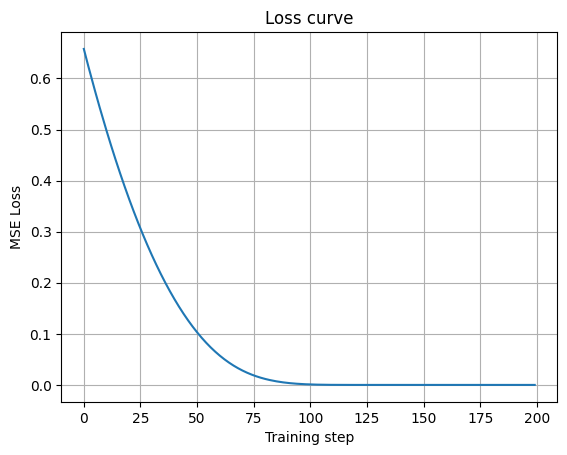

In [24]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('Training step')
plt.ylabel('MSE Loss')
plt.title('Loss curve')
plt.grid(True)
plt.show()

### Exercise: Train with a different optimizer

Repeat the training loop above but use `torch.optim.SGD` with `lr=0.01` instead of Adam. Plot the loss curve and compare it to the Adam result. What do you observe?

In [18]:
# YOUR CODE HERE
